
Done (single video). Outputs saved to: D:\Trial


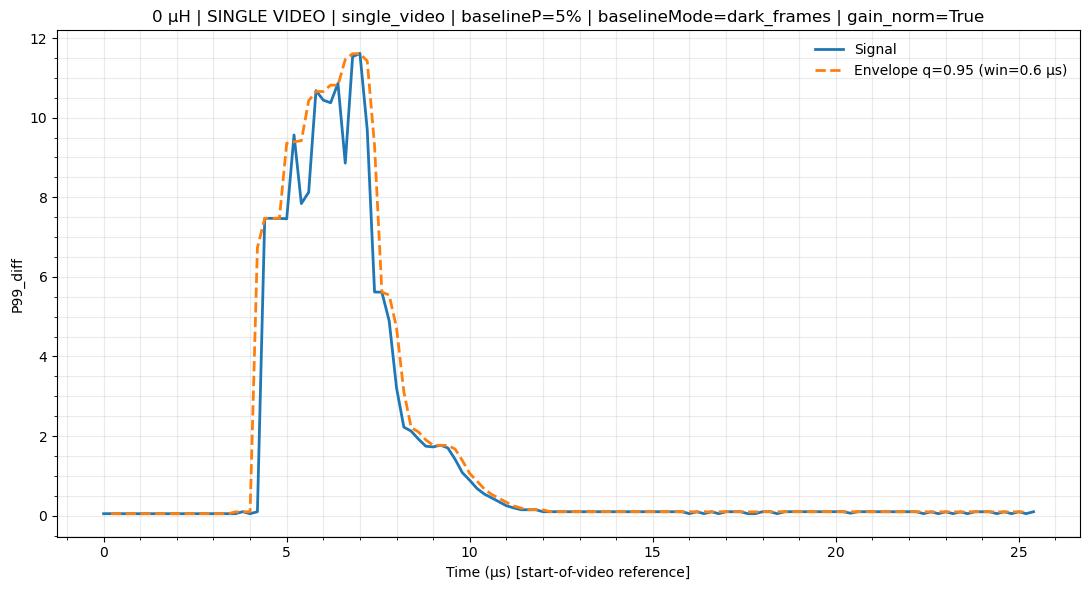

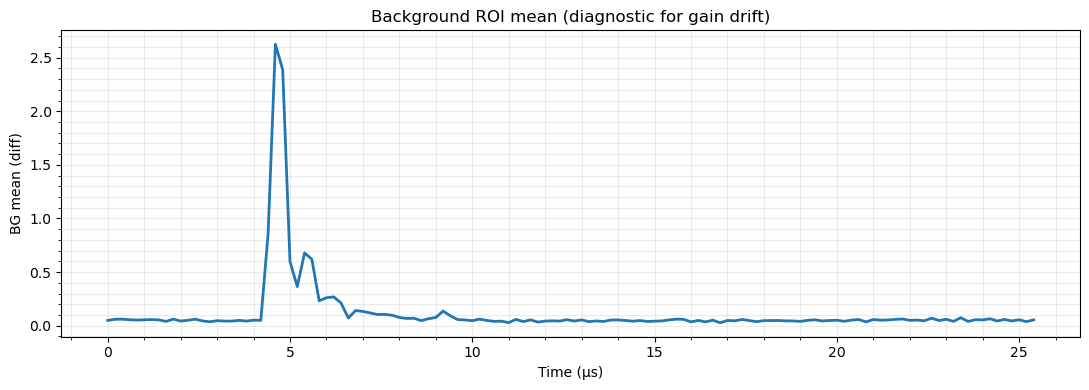

In [51]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator

# ============================================================
# CONFIG (EDIT THESE)
# ============================================================

OUT_DIR = Path(r"D:\Trial")
OUT_DIR.mkdir(parents=True, exist_ok=True)

INDUCTANCE_UH = 0

# -----------------------------
# NEW: RUN MODE
# -----------------------------
# "stitch"       -> multi-delay stitching (original pipeline)
# "single_video" -> process exactly ONE video (no stitching)
RUN_MODE = "single_video"  # "stitch" or "single_video"

# -----------------------------
# SINGLE VIDEO SETTINGS (used only if RUN_MODE="single_video")
# -----------------------------
SINGLE_VIDEO_PATH = Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\0 uH\FPS= 5 mil\Delay_0ns\Camera_17_14_24.avi")
SINGLE_LABEL = "single_video"  # used in filenames/titles

# -----------------------------
# STITCH SETTINGS (used only if RUN_MODE="stitch")
# -----------------------------
DELAY_DIRS = {
    0:     Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\560 uH\FPS= 5 mil\Delay_0ns"),
    18000: Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\560 uH\FPS= 5 mil\Delay_18000ns"),
    36000: Path(r"C:\Users\Shabab Bin Karim\Desktop\SDG Spark Videos\Videos\560 uH\FPS= 5 mil\Delay_36000ns"),
}

FPS_TRUE = 5_000_000
ROTATE_DEG = 0

# Main ROI (your discharge ROI)
ROI = (1, 1, 355, 245)  # x,y,w,h

# Background ROI (quiet region; adjust if needed)
ROI_BG = (0, 0, 50, 50)  # x,y,w,h

# Local time window (within each video, start-of-video reference)
LOCAL_START_US = 0.0
LOCAL_END_US   = 35.0

# Baseline percentile (robust)
BASELINE_PERCENTILE = 5.0

# Baseline mode: used in your newer versions (keep as-is)
# "all_frames" (percentile across all frames) OR "dark_frames" (subset of darkest frames)
BASELINE_MODE = "dark_frames"  # "all_frames" or "dark_frames"

# ============================================================
# VIDEO SELECTION (stitch mode)
# ============================================================
# "batch"  -> average over all videos per delay
# "single" -> use one video per delay
VIDEO_MODE = "single"  # "batch" or "single"

SINGLE_VIDEO_BY_DELAY = {
    0:     "Camera_16_25_50.avi",
    18000: "Camera_16_28_07.avi",
    36000: "Camera_16_30_19.avi",
}

EXCLUDE_STEMS = set([
    # "bad_video_001",
])

# ============================================================
# SIGNAL METRIC
# ============================================================
# Options:
#   "Sum_diff"        -> sum of all positive diff pixels (best for slow decay)
#   "SumBright_diff"  -> sum of diff pixels above PIX_THR (core-weighted)
#   "P99_diff"        -> 99th percentile of diff (peak-weighted)
SIGNAL_MODE = "P99_diff"
PIX_THR = 10  # used only for SumBright_diff

# ============================================================
# GAIN / BACKGROUND NORMALIZATION
# ============================================================
ENABLE_GAIN_NORM = True
GAIN_EPS = 1.0
GAIN_REF_STAT = "median"  # "median" or "mean"

# Clip BG to reduce rare spikes (recommended ON for stability)
ENABLE_GAIN_BG_CLIP = True
GAIN_BG_CLIP_PCTS = (2.0, 98.0)

# ============================================================
# TIME ALIGNMENT (stitch mode; safe to leave ON, ignored in single_video)
# ============================================================
ENABLE_PAIRWISE_TIME_ALIGN = True
TIME_ALIGN_MAX_SHIFT_US = 3.0
TIME_ALIGN_WINDOW_US = 8.0
TIME_ALIGN_SMOOTH_SAMPLES = 5

# ============================================================
# SCALE MATCHING (stitch mode)
# ============================================================
ENABLE_SCALE_MATCH = True
SCALE_MATCH_WINDOW_US = 2.0
SCALE_MATCH_PERCENTILE = 90.0
SCALE_MATCH_CLIP = (0.5, 2.0)

# ============================================================
# STITCHING
# ============================================================
DT_STITCH_US = 0.05
MAX_GLOBAL_POINTS = 400_000
ENABLE_SMOOTH_SPLICE = True
BLEND_HALF_WIDTH_US = 1.0

# ============================================================
# ENVELOPE
# ============================================================
ENABLE_ENVELOPE = True
ENVELOPE_WINDOW_US = 0.6
ENVELOPE_Q = 0.95

# ============================================================
# PLOTTING
# ============================================================
USE_LOG_Y = False
LOG_EPS = 1.0

# ============================================================
# OPTIONAL DIFF DENOISE / DIAGNOSTICS
# ============================================================
ENABLE_DIFF_DENOISE = False
DENOISE_METHOD = "median3"

ENABLE_AREA_FRAC = False
AREA_THR = 10

# ============================================================
# HELPERS
# ============================================================

def format_ticks(ax):
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which="both", alpha=0.25)

def rotate_frame(frame_bgr, angle_deg):
    if angle_deg == 0:
        return frame_bgr
    h, w = frame_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(frame_bgr, M, (w, h), flags=cv2.INTER_LINEAR)

def list_videos(folder: Path):
    exts = (".avi", ".mp4", ".mov", ".mkv")
    vids = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts]
    vids.sort()
    return vids

def select_videos_for_delay(folder: Path, delay_ns: int):
    vids = list_videos(folder)
    if len(vids) == 0:
        return []
    mode = VIDEO_MODE.lower().strip()
    if mode == "batch":
        return [v for v in vids if v.stem not in EXCLUDE_STEMS]
    if mode == "single":
        name = SINGLE_VIDEO_BY_DELAY.get(delay_ns, None)
        if name is None:
            return []
        vp = folder / name
        return [vp] if vp.exists() else []
    raise ValueError("VIDEO_MODE must be 'batch' or 'single'")

def resample_to_grid(t_src, y_src, t_grid):
    return np.interp(t_grid, t_src, y_src, left=np.nan, right=np.nan)

def nanmean_sd(W):
    mean = np.nanmean(W, axis=0)
    sd = np.nanstd(W, axis=0, ddof=1) if W.shape[0] > 1 else np.full(W.shape[1], np.nan)
    return mean, sd

def extract_valid_segment(t, mean, sd):
    m = np.isfinite(mean)
    if not np.any(m):
        return np.array([]), np.array([]), np.array([])
    i0 = int(np.argmax(m))
    i1 = int(len(m) - 1 - np.argmax(m[::-1]))
    return t[i0:i1+1], mean[i0:i1+1], sd[i0:i1+1]

def build_safe_global_grid(t_min, t_max, dt_stitch_us, max_points):
    if t_max <= t_min:
        return np.array([t_min], dtype=float)
    dtg = float(dt_stitch_us)
    n_est = int(np.ceil((t_max - t_min) / dtg)) + 1
    if n_est > max_points:
        dtg = (t_max - t_min) / (max_points - 1)
    t = np.arange(t_min, t_max + dtg, dtg)
    if t.size > max_points:
        t = np.linspace(t_min, t_max, max_points)
    return t

def smoothstep(x):
    x = np.clip(x, 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)

def rolling_quantile_envelope(t, y, window_us, q):
    dt = float(np.median(np.diff(t))) if t.size > 2 else window_us
    win = max(3, int(round(window_us / dt)))
    s = pd.Series(y)
    env = s.rolling(win, center=True, min_periods=max(3, win//5)).quantile(q).to_numpy()
    return env

def _denoise_diff_to_int16(diff_int16):
    if not ENABLE_DIFF_DENOISE:
        return diff_int16
    if DENOISE_METHOD == "median3":
        d8 = np.clip(diff_int16, 0, 255).astype(np.uint8)
        d8 = cv2.medianBlur(d8, 3)
        return d8.astype(np.int16)
    raise ValueError("Unknown DENOISE_METHOD")

def _baseline_from_stack(stack_uint8, p):
    # stack: (T,H,W) uint8
    return np.percentile(stack_uint8, float(p), axis=0).astype(np.int16)

def compute_baseline_percentile(video_path: Path, roi_xywh, rotate_deg=0, p=5.0):
    x, y, w, h = roi_xywh
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    stack = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = rotate_frame(frame, rotate_deg)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        roi = gray[y:y+h, x:x+w]
        if roi.size == 0:
            cap.release()
            raise ValueError(f"ROI out of bounds for {video_path}. ROI={roi_xywh}, frame={gray.shape}")
        stack.append(roi.astype(np.uint8))

    cap.release()
    if len(stack) == 0:
        raise RuntimeError(f"No frames read from: {video_path}")

    stack = np.stack(stack, axis=0)  # (T,H,W)

    if BASELINE_MODE.lower().strip() == "all_frames":
        return _baseline_from_stack(stack, p)

    if BASELINE_MODE.lower().strip() == "dark_frames":
        # Pick darkest frames based on mean intensity in ROI, then take percentile over them
        means = stack.reshape(stack.shape[0], -1).mean(axis=1)
        k = max(5, int(round(0.25 * stack.shape[0])))  # darkest 25% (min 5)
        idx = np.argsort(means)[:k]
        return _baseline_from_stack(stack[idx], p)

    raise ValueError("BASELINE_MODE must be 'all_frames' or 'dark_frames'")

# ============================================================
# SIGNAL EXTRACTION (single video)
# ============================================================

def compute_signal_trace(video_path: Path):
    base_main = compute_baseline_percentile(video_path, ROI, rotate_deg=ROTATE_DEG, p=BASELINE_PERCENTILE)
    base_bg   = compute_baseline_percentile(video_path, ROI_BG, rotate_deg=ROTATE_DEG, p=BASELINE_PERCENTILE)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dt_us = 1e6 / FPS_TRUE

    t_us = np.zeros(n_frames, dtype=float)
    sig  = np.zeros(n_frames, dtype=float)
    bg   = np.zeros(n_frames, dtype=float)

    area_frac = np.full(n_frames, np.nan, dtype=float) if ENABLE_AREA_FRAC else None

    x, y, w, h = ROI
    xb, yb, wb, hb = ROI_BG

    for i in range(n_frames):
        ok, frame = cap.read()
        if not ok:
            t_us = t_us[:i]
            sig  = sig[:i]
            bg   = bg[:i]
            if ENABLE_AREA_FRAC:
                area_frac = area_frac[:i]
            break

        frame = rotate_frame(frame, ROTATE_DEG)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        roi_main = gray[y:y+h, x:x+w].astype(np.int16)
        diff = roi_main - base_main
        diff[diff < 0] = 0
        diff = _denoise_diff_to_int16(diff)

        roi_bg = gray[yb:yb+hb, xb:xb+wb].astype(np.int16)
        diff_bg = roi_bg - base_bg
        diff_bg[diff_bg < 0] = 0

        bg[i] = float(np.mean(diff_bg))

        if ENABLE_AREA_FRAC:
            area_frac[i] = float(np.mean(diff > float(AREA_THR)))

        if SIGNAL_MODE == "Sum_diff":
            val = float(np.sum(diff))
        elif SIGNAL_MODE == "SumBright_diff":
            mask = diff >= int(PIX_THR)
            val = float(np.sum(diff[mask])) if np.any(mask) else 0.0
        elif SIGNAL_MODE == "P99_diff":
            val = float(np.percentile(diff, 99))
        else:
            raise ValueError("SIGNAL_MODE must be one of: Sum_diff, SumBright_diff, P99_diff")

        sig[i] = val
        t_us[i] = i * dt_us

    cap.release()

    # Gain normalization
    if ENABLE_GAIN_NORM:
        bg_use = bg.copy()
        if ENABLE_GAIN_BG_CLIP and np.any(np.isfinite(bg_use)):
            lo, hi = np.percentile(bg_use[np.isfinite(bg_use)], [GAIN_BG_CLIP_PCTS[0], GAIN_BG_CLIP_PCTS[1]])
            bg_use = np.clip(bg_use, lo, hi)

        valid = np.isfinite(bg_use)
        if np.any(valid):
            ref = float(np.median(bg_use[valid])) if GAIN_REF_STAT == "median" else float(np.mean(bg_use[valid]))
            sig = sig * (ref / (bg_use + GAIN_EPS))

    return t_us, sig, bg

# ============================================================
# BUILD SEGMENTS (stitch mode)
# ============================================================

def build_segment_for_delay(delay_ns: int, vids, t_local):
    Ys = []
    BGs = []
    used = []
    rej = []

    for vp in vids:
        if vp.stem in EXCLUDE_STEMS:
            rej.append((delay_ns, vp.name, "excluded_by_list"))
            continue
        try:
            t_us_arr, y_raw, bg_raw = compute_signal_trace(vp)
            t_rel = t_us_arr - float(t_us_arr[0])

            y_win  = resample_to_grid(t_rel, y_raw,  t_local)
            bg_win = resample_to_grid(t_rel, bg_raw, t_local)

            Ys.append(y_win)
            BGs.append(bg_win)
            used.append(vp.name)
        except Exception as e:
            rej.append((delay_ns, vp.name, f"error:{type(e).__name__}:{str(e)[:160]}"))
            continue

    if len(Ys) == 0:
        return None, rej

    W = np.vstack(Ys)
    mean, sd = nanmean_sd(W)

    BGW = np.vstack(BGs)
    bg_mean = np.nanmean(BGW, axis=0)

    t_v, mean_v, sd_v = extract_valid_segment(t_local, mean, sd)
    if t_v.size == 0:
        return None, rej

    seg = {
        "delay_ns": delay_ns,
        "t_local": t_local,
        "mean_local": mean,
        "sd_local": sd,
        "bg_mean_local": bg_mean,
        "t_valid": t_v,
        "mean_valid": mean_v,
        "sd_valid": sd_v,
        "n": W.shape[0],
        "used_files": used,
    }
    return seg, rej

# ============================================================
# SCALE MATCH (stitch mode)
# ============================================================

def _window_mask(t, t0, halfwin):
    return (t >= (t0 - halfwin)) & (t <= (t0 + halfwin))

def estimate_scale_factor(tA, yA, tB, yB, t0, window_us, pct):
    mA = _window_mask(tA, t0, window_us)
    mB = _window_mask(tB, t0, window_us)
    if not (np.any(mA) and np.any(mB)):
        return 1.0

    a = yA[mA]
    b = yB[mB]
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 10) or (b.size < 10):
        return 1.0

    qa = float(np.percentile(a, pct))
    qb = float(np.percentile(b, pct))
    if qb <= 0:
        return 1.0
    return qa / qb

# ============================================================
# TIME ALIGN (stitch mode)
# ============================================================

def _smooth_for_match(y, k):
    if k <= 1:
        return y
    s = pd.Series(y)
    return s.rolling(k, center=True, min_periods=max(3, k//3)).mean().to_numpy()

def best_time_shift_us(t_grid, A, B, max_shift_us, dt_us):
    # Search integer shifts on the grid
    max_samp = int(round(max_shift_us / dt_us))
    if max_samp < 1:
        return 0.0
    best_sse = np.inf
    best_shift = 0

    for s in range(-max_samp, max_samp + 1):
        if s < 0:
            AA = A[-s:]
            BB = B[:len(AA)]
        elif s > 0:
            AA = A[:-s]
            BB = B[s:]
        else:
            AA = A
            BB = B

        ok = np.isfinite(AA) & np.isfinite(BB)
        if np.sum(ok) < 30:
            continue

        AA0 = AA[ok] - np.median(AA[ok])
        BB0 = BB[ok] - np.median(BB[ok])
        sse = float(np.mean((AA0 - BB0) ** 2))
        if sse < best_sse:
            best_sse = sse
            best_shift = s

    return float(best_shift) * dt_us

# ============================================================
# RUN: SINGLE VIDEO (no stitching)
# ============================================================

def run_single_video():
    if not SINGLE_VIDEO_PATH.exists():
        raise FileNotFoundError(f"SINGLE_VIDEO_PATH not found: {SINGLE_VIDEO_PATH}")

    t_us, sig, bg = compute_signal_trace(SINGLE_VIDEO_PATH)
    t_rel = t_us - float(t_us[0])

    # apply local window
    m = (t_rel >= float(LOCAL_START_US)) & (t_rel <= float(LOCAL_END_US))
    t_plot = t_rel[m]
    y_plot = sig[m]
    bg_plot = bg[m]

    env = None
    if ENABLE_ENVELOPE and t_plot.size >= 5:
        env = rolling_quantile_envelope(t_plot, y_plot, ENVELOPE_WINDOW_US, ENVELOPE_Q)

    # Plot signal
    fig, ax = plt.subplots(figsize=(11, 6))
    if USE_LOG_Y:
        ax.set_yscale("log")
        ax.plot(t_plot, np.maximum(y_plot + LOG_EPS, 1e-12), linewidth=2, label="Signal")
        if env is not None:
            ax.plot(t_plot, np.maximum(env + LOG_EPS, 1e-12), linestyle="--", linewidth=2,
                    label=f"Envelope q={ENVELOPE_Q} (win={ENVELOPE_WINDOW_US} µs)")
        ax.set_ylabel(SIGNAL_MODE + " (+eps) [log]")
    else:
        ax.plot(t_plot, y_plot, linewidth=2, label="Signal")
        if env is not None:
            ax.plot(t_plot, env, linestyle="--", linewidth=2,
                    label=f"Envelope q={ENVELOPE_Q} (win={ENVELOPE_WINDOW_US} µs)")
        ax.set_ylabel(SIGNAL_MODE)

    ax.set_xlabel("Time (µs) [start-of-video reference]")
    ax.set_title(
        f"{INDUCTANCE_UH} µH | SINGLE VIDEO | {SINGLE_LABEL} | "
        f"baselineP={int(BASELINE_PERCENTILE)}% | baselineMode={BASELINE_MODE} | "
        f"gain_norm={ENABLE_GAIN_NORM}"
    )
    ax.legend(frameon=False)
    format_ticks(ax)
    fig.tight_layout()

    out_png = OUT_DIR / f"single_{SINGLE_LABEL}_baselineP{int(BASELINE_PERCENTILE)}_{BASELINE_MODE}_gain{int(ENABLE_GAIN_NORM)}_{SIGNAL_MODE}.png"
    fig.savefig(out_png, dpi=300)

    # Plot BG diagnostic
    fig2, ax2 = plt.subplots(figsize=(11, 4))
    ax2.plot(t_plot, bg_plot, linewidth=2)
    ax2.set_xlabel("Time (µs)")
    ax2.set_ylabel("BG mean (diff)")
    ax2.set_title("Background ROI mean (diagnostic for gain drift)")
    format_ticks(ax2)
    fig2.tight_layout()
    fig2.savefig(OUT_DIR / f"single_{SINGLE_LABEL}_bg_mean_diagnostic.png", dpi=300)

    # Save CSV
    df = pd.DataFrame({"t_us": t_plot, "signal": y_plot, "bg_mean": bg_plot})
    if env is not None:
        df["envelope"] = env
    df.to_csv(
        OUT_DIR / f"single_{SINGLE_LABEL}_baselineP{int(BASELINE_PERCENTILE)}_{BASELINE_MODE}_gain{int(ENABLE_GAIN_NORM)}_{SIGNAL_MODE}.csv",
        index=False
    )

    print("\nDone (single video). Outputs saved to:", OUT_DIR)

# ============================================================
# RUN: STITCH (original pipeline)
# ============================================================

def run_stitch():
    for d_ns, folder in DELAY_DIRS.items():
        if not folder.exists():
            raise FileNotFoundError(f"Delay {d_ns} ns folder not found: {folder}")

    delays_sorted = sorted(DELAY_DIRS.keys())
    if 0 not in delays_sorted:
        raise ValueError("DELAY_DIRS must include 0 ns.")

    dt_local = 1e6 / FPS_TRUE
    t_local = np.arange(LOCAL_START_US, LOCAL_END_US + dt_local, dt_local)

    print("\n=== RUN SETTINGS ===")
    print(f"RUN_MODE: {RUN_MODE}")
    print(f"Inductance: {INDUCTANCE_UH} uH | fps_true: {FPS_TRUE}")
    print(f"Delays (ns): {delays_sorted}")
    print(f"VIDEO_MODE: {VIDEO_MODE}")
    if VIDEO_MODE.lower() == "single":
        print(f"SINGLE_VIDEO_BY_DELAY: {SINGLE_VIDEO_BY_DELAY}")
    print(f"ROI(main): {ROI} | ROI_BG: {ROI_BG}")
    print(f"Signal: {SIGNAL_MODE} (PIX_THR={PIX_THR})")
    print(f"Baseline percentile: {BASELINE_PERCENTILE}% | BASELINE_MODE={BASELINE_MODE}")
    print(f"Gain norm: {ENABLE_GAIN_NORM} (ref={GAIN_REF_STAT}, eps={GAIN_EPS}, clip={ENABLE_GAIN_BG_CLIP}, clip_pcts={GAIN_BG_CLIP_PCTS})")
    print(f"Time-align: {ENABLE_PAIRWISE_TIME_ALIGN} (max_shift={TIME_ALIGN_MAX_SHIFT_US} us, window={TIME_ALIGN_WINDOW_US} us)")
    print(f"Scale match: {ENABLE_SCALE_MATCH} (win={SCALE_MATCH_WINDOW_US} us, pct={SCALE_MATCH_PERCENTILE}, clip={SCALE_MATCH_CLIP})")
    print(f"Splice blend: {ENABLE_SMOOTH_SPLICE} (bw={BLEND_HALF_WIDTH_US} us)")
    print(f"Envelope: {ENABLE_ENVELOPE} (q={ENVELOPE_Q}, win={ENVELOPE_WINDOW_US} us)")
    print("====================\n")

    segments = []
    rejection_log = []

    for d_ns in delays_sorted:
        vids = select_videos_for_delay(DELAY_DIRS[d_ns], d_ns)
        if len(vids) == 0:
            print(f"WARNING: delay {d_ns} ns -> no videos selected")
            continue

        seg, rej = build_segment_for_delay(d_ns, vids, t_local)
        rejection_log.extend(rej)

        if seg is None:
            print(f"WARNING: delay {d_ns} ns -> no usable videos")
            continue

        segments.append(seg)
        print(f"Delay {d_ns} ns: used {seg['n']} | files={seg['used_files']}")

    if len(segments) < 2:
        raise RuntimeError("Need at least 2 delays/segments to stitch.")

    segments.sort(key=lambda s: s["delay_ns"])

    pd.DataFrame(rejection_log, columns=["delay_ns", "filename", "reason"]).to_csv(
        OUT_DIR / "rejections.csv", index=False
    )
    pd.DataFrame([{
        "delay_ns": s["delay_ns"],
        "n_used": s["n"],
        "files": ";".join(s["used_files"])
    } for s in segments]).to_csv(OUT_DIR / "used_files_by_delay.csv", index=False)

    # nominal global placement
    for s in segments:
        delay_us = s["delay_ns"] / 1000.0
        s["t_global_nom"] = s["t_valid"] + delay_us

    # global grid
    t_min = min(float(s["t_global_nom"][0]) for s in segments)
    t_max = max(float(s["t_global_nom"][-1]) for s in segments)
    t_grid = build_safe_global_grid(t_min, t_max, DT_STITCH_US, MAX_GLOBAL_POINTS)
    dtg = float(np.median(np.diff(t_grid))) if t_grid.size > 2 else DT_STITCH_US

    # resample each segment to global grid
    segY = []
    segSD = []
    starts = []

    for s in segments:
        y_g = resample_to_grid(s["t_global_nom"], s["mean_valid"], t_grid)
        sd_g = resample_to_grid(s["t_global_nom"], s["sd_valid"], t_grid)
        segY.append(y_g)
        segSD.append(sd_g)
        starts.append(float(s["delay_ns"] / 1000.0 + s["t_valid"][0]))

    # Pairwise time alignment (shift later segment onto previous)
    if ENABLE_PAIRWISE_TIME_ALIGN and len(segments) >= 2:
        for i in range(len(segments) - 1):
            # define overlap window around next start
            t0 = starts[i + 1]
            win = float(TIME_ALIGN_WINDOW_US)
            m = (t_grid >= (t0 - win)) & (t_grid <= (t0 + win))
            if np.sum(m) < 50:
                continue

            A = _smooth_for_match(segY[i][m], TIME_ALIGN_SMOOTH_SAMPLES)
            B = _smooth_for_match(segY[i + 1][m], TIME_ALIGN_SMOOTH_SAMPLES)

            shift = best_time_shift_us(t_grid[m], A, B, TIME_ALIGN_MAX_SHIFT_US, dtg)
            if abs(shift) > 1e-12:
                # apply shift to segment i+1 by shifting its samples on the global grid
                segY[i + 1] = np.interp(t_grid, t_grid + shift, segY[i + 1], left=np.nan, right=np.nan)
                segSD[i + 1] = np.interp(t_grid, t_grid + shift, segSD[i + 1], left=np.nan, right=np.nan)
                starts[i + 1] = starts[i + 1] - shift

    # Scale match at splice (match later segment amplitude to previous)
    if ENABLE_SCALE_MATCH and len(segments) >= 2:
        for i in range(len(segments) - 1):
            t0 = starts[i + 1]
            fac = estimate_scale_factor(
                t_grid, segY[i],
                t_grid, segY[i + 1],
                t0=t0, window_us=float(SCALE_MATCH_WINDOW_US),
                pct=float(SCALE_MATCH_PERCENTILE)
            )
            lo, hi = float(SCALE_MATCH_CLIP[0]), float(SCALE_MATCH_CLIP[1])
            fac = float(np.clip(fac, lo, hi))
            segY[i + 1] = segY[i + 1] * fac
            segSD[i + 1] = segSD[i + 1] * fac

    # Plot segments overlay (global time)
    fig, ax = plt.subplots(figsize=(11, 6))
    for s in segments:
        delay_us = s["delay_ns"] / 1000.0
        y = s["mean_valid"]
        t = s["t_valid"] + delay_us
        if USE_LOG_Y:
            ax.set_yscale("log")
            ax.plot(t, np.maximum(y + LOG_EPS, 1e-12), linewidth=2, label=f"Delay={delay_us:.3f} µs (n={s['n']})")
        else:
            ax.plot(t, y, linewidth=2, label=f"Delay={delay_us:.3f} µs (n={s['n']})")

    ax.set_xlabel("Global time (µs) [start-of-video reference]")
    ax.set_ylabel(SIGNAL_MODE + (" (+eps) [log]" if USE_LOG_Y else ""))
    ax.set_title(
        f"{INDUCTANCE_UH} µH | GlobalTime=by_delay | mode={VIDEO_MODE} | "
        f"baselineP={int(BASELINE_PERCENTILE)}% | baselineMode={BASELINE_MODE} | "
        f"time_align={ENABLE_PAIRWISE_TIME_ALIGN} | scale_match={ENABLE_SCALE_MATCH} | gain_norm={ENABLE_GAIN_NORM}"
    )
    ax.legend(frameon=False)
    format_ticks(ax)
    fig.tight_layout()
    fig.savefig(
        OUT_DIR / f"segments_overlay_mode_{VIDEO_MODE}_baselineP{int(BASELINE_PERCENTILE)}_{BASELINE_MODE}"
                  f"_timealign{int(ENABLE_PAIRWISE_TIME_ALIGN)}_scalematch{int(ENABLE_SCALE_MATCH)}"
                  f"_gain{int(ENABLE_GAIN_NORM)}_{SIGNAL_MODE}.png",
        dpi=300
    )

    # ========================================================
    # STITCH (sequential overwrite + symmetric crossfade)
    # ========================================================
    stitched_mean = np.full_like(t_grid, np.nan, dtype=float)
    stitched_sd   = np.full_like(t_grid, np.nan, dtype=float)

    stitched_mean[:] = segY[0]
    stitched_sd[:]   = segSD[0]

    if len(segments) >= 2 and ENABLE_SMOOTH_SPLICE:
        bw = float(BLEND_HALF_WIDTH_US)

        for i in range(len(segments) - 1):
            t0 = starts[i + 1]
            tL = t0 - bw
            tR = t0 + bw

            y_next  = segY[i + 1]
            sd_next = segSD[i + 1]

            m_after = (t_grid > tR) & np.isfinite(y_next)
            stitched_mean[m_after] = y_next[m_after]
            stitched_sd[m_after]   = sd_next[m_after]

            m_blend = (t_grid >= tL) & (t_grid <= tR)
            if not np.any(m_blend):
                continue

            yA  = stitched_mean[m_blend]
            yB  = y_next[m_blend]
            sdA = stitched_sd[m_blend]
            sdB = sd_next[m_blend]

            ok = np.isfinite(yA) & np.isfinite(yB)
            if np.sum(ok) < 20:
                m_hard = (t_grid >= t0) & np.isfinite(y_next)
                stitched_mean[m_hard] = y_next[m_hard]
                stitched_sd[m_hard]   = sd_next[m_hard]
                continue

            wlin = (t_grid[m_blend][ok] - tL) / (tR - tL)
            wgt = smoothstep(wlin)

            y_out  = yA.copy()
            sd_out = sdA.copy()
            y_out[ok]  = (1.0 - wgt) * yA[ok]  + wgt * yB[ok]
            sd_out[ok] = (1.0 - wgt) * sdA[ok] + wgt * sdB[ok]

            stitched_mean[m_blend] = y_out
            stitched_sd[m_blend]   = sd_out
    else:
        for i in range(len(segments) - 1):
            t0 = starts[i + 1]
            y_next  = segY[i + 1]
            sd_next = segSD[i + 1]
            m = (t_grid >= t0) & np.isfinite(y_next)
            stitched_mean[m] = y_next[m]
            stitched_sd[m]   = sd_next[m]

    # Envelope on stitched signal
    envelope = None
    if ENABLE_ENVELOPE:
        envelope = rolling_quantile_envelope(t_grid, stitched_mean, ENVELOPE_WINDOW_US, ENVELOPE_Q)

    # Plot stitched
    fig2, ax2 = plt.subplots(figsize=(11, 6))
    if USE_LOG_Y:
        ax2.set_yscale("log")
        ax2.plot(t_grid, np.maximum(stitched_mean + LOG_EPS, 1e-12), linewidth=2, label="Stitched")
        if envelope is not None:
            ax2.plot(t_grid, np.maximum(envelope + LOG_EPS, 1e-12), linestyle="--", linewidth=2,
                     label=f"Envelope q={ENVELOPE_Q} (win={ENVELOPE_WINDOW_US} µs)")
        ax2.set_ylabel(SIGNAL_MODE + " (+eps) [log]")
    else:
        ax2.plot(t_grid, stitched_mean, linewidth=2, label="Stitched")
        ax2.fill_between(t_grid, stitched_mean - stitched_sd, stitched_mean + stitched_sd, alpha=0.18)
        if envelope is not None:
            ax2.plot(t_grid, envelope, linestyle="--", linewidth=2,
                     label=f"Envelope q={ENVELOPE_Q} (win={ENVELOPE_WINDOW_US} µs)")
        ax2.set_ylabel(SIGNAL_MODE)

    ax2.set_xlabel("Reconstructed discharge time (µs) [start-of-video reference]")
    ax2.set_title(
        f"{INDUCTANCE_UH} µH | Stitched | mode={VIDEO_MODE} | "
        f"baselineP={int(BASELINE_PERCENTILE)}% | baselineMode={BASELINE_MODE} | "
        f"time_align={ENABLE_PAIRWISE_TIME_ALIGN} | scale_match={ENABLE_SCALE_MATCH} | "
        f"gain_norm={ENABLE_GAIN_NORM} | bw={BLEND_HALF_WIDTH_US} µs"
    )
    ax2.legend(frameon=False)
    format_ticks(ax2)
    fig2.tight_layout()
    fig2.savefig(
        OUT_DIR / f"stitched_mode_{VIDEO_MODE}_baselineP{int(BASELINE_PERCENTILE)}_{BASELINE_MODE}"
                  f"_timealign{int(ENABLE_PAIRWISE_TIME_ALIGN)}_scalematch{int(ENABLE_SCALE_MATCH)}"
                  f"_gain{int(ENABLE_GAIN_NORM)}_{SIGNAL_MODE}_bw{BLEND_HALF_WIDTH_US:.1f}.png",
        dpi=300
    )

    # Save CSV
    out_csv = pd.DataFrame({"t_us": t_grid, "mean": stitched_mean, "sd": stitched_sd})
    if envelope is not None:
        out_csv["envelope"] = envelope
    out_csv.to_csv(
        OUT_DIR / f"stitched_mode_{VIDEO_MODE}_baselineP{int(BASELINE_PERCENTILE)}_{BASELINE_MODE}"
                  f"_timealign{int(ENABLE_PAIRWISE_TIME_ALIGN)}_scalematch{int(ENABLE_SCALE_MATCH)}"
                  f"_gain{int(ENABLE_GAIN_NORM)}_{SIGNAL_MODE}.csv",
        index=False
    )

    # BG diagnostic (by delay)
    fig3, ax3 = plt.subplots(figsize=(11, 4))
    for s in segments:
        ax3.plot(
            s["t_local"] + (s["delay_ns"]/1000.0),
            s["bg_mean_local"],
            linewidth=2,
            label=f"BG mean | delay={s['delay_ns']/1000:.3f} µs (n={s['n']})"
        )
    ax3.set_xlabel("Global time (µs)")
    ax3.set_ylabel("BG mean (diff)")
    ax3.set_title("Background ROI mean (diagnostic for gain drift)")
    ax3.legend(frameon=False)
    format_ticks(ax3)
    fig3.tight_layout()
    fig3.savefig(OUT_DIR / "bg_mean_diagnostic.png", dpi=300)

    print("\nDone (stitch). Outputs saved to:", OUT_DIR)

# ============================================================
# MAIN
# ============================================================

def main():
    mode = RUN_MODE.lower().strip()
    if mode in ("single_video", "single", "one"):
        run_single_video()
    elif mode in ("stitch", "stitched"):
        run_stitch()
    else:
        raise ValueError("RUN_MODE must be 'stitch' or 'single_video'")

if __name__ == "__main__":
    main()